
# ReprocessScanMictools.py

Parametric script to re-process ISN flyscans using the mictools library.

You can adjust the scan number and ROI parameters in the Control Panel below.

In [12]:
# --- Imports ---
import os
import sys
import matplotlib.pyplot as plt

# Add the parent directory to the python path so it can import the 'mictools' folder
sys.path.append(os.path.abspath('..'))

# Standard mictools imports from Pedro's workflow
from mictools.config import *
from mictools.peak_modelling import *
from mictools.roi_utils import Roi
from mictools.process_data import *
from mictools.plot_data import *

In [13]:
# --- Configuration ---
# Point mictools to the main raw data directory
set_path('/Volumes/data1/isn/2026-1/2026-1-Harder')

# -- 1. Core Scan Parameters
SCAN_NUM = 99          # The flyscan number to process
DETECTOR = 'me7'       # 'me7' for fluorescence, 'xrd' for diffraction

# -- 2. ROI Parameters (Molybdenum K-alpha pure Mo ROI)
# Y-axis = detector elements (0 to 7)
Y_START = 0
Y_END = 7

#.-- X-axis = spectral channels
# X_START = 955 #Au L_aplh_1
# X_END = 985
X_START = 1730 #Mo_Ka
X_END = 1760

ROI_NAME = 'Mo_Ka'
# ROI_NAME = 'Au_L_alph'
ROI_TYPE = 'Intensity' # 'Intensity' for XRF counts, 'COM_X'/'COM_Y' for XRD peak centers

Loading and processing Scan 99...
Targeting Mo_Ka ROI from channel 1730 to 1760...


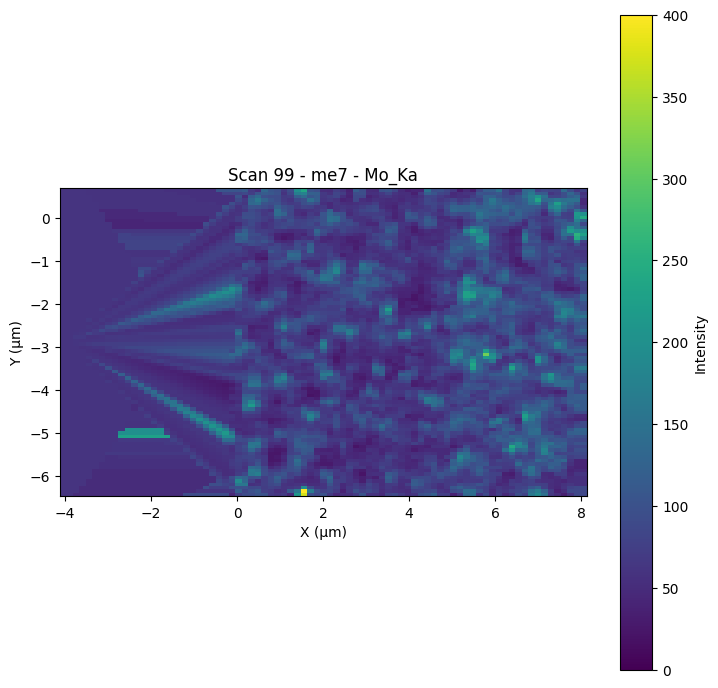

In [14]:
if __name__ == "__main__":
    print(f"Loading and processing Scan {SCAN_NUM}...")
    print(f"Targeting {ROI_NAME} ROI from channel {X_START} to {X_END}...")

    # Initialize the Region of Interest
    target_roi = Roi(Y_START, Y_END, X_START, X_END, name=ROI_NAME)

    #Set Figure size
    plt.rcParams['figure.figsize'] = [8.5, 8.5] 

    # Plot the flyscan interpolation directly using the wrapper
    plot_flyscan(scanno=SCAN_NUM, detector=DETECTOR, roi=target_roi, roi_type=ROI_TYPE,
             vmin=0, vmax=400)
